In [14]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely import contains_xy

from atlas import indices, ingest
from atlas.indices import UTCI_STRESS


In [15]:
mex = xr.open_dataset("../data/raw/ECMWF_utci_2022_mexico_anual.nc")
mex

<xarray.Dataset> Size: 359MB
Dimensions:  (time: 8760, lat: 77, lon: 133)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2022-01-01 ... 2022-12-31T23:00:00
  * lat      (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.75 14.5 14.25 14.0
  * lon      (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.5 -86.25 -86.0
Data variables:
    utci     (time, lat, lon) float32 359MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.8 (https://...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.8 (https://...
    cdo_openmp_thread_number:  8
    history:                   Mon Apr  4 07:54:18 2022: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.7.8 (Homepage = htt...

In [16]:
cube = ingest._normalize(mex, tipo="UTCI")


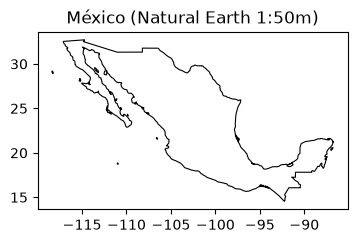

In [17]:
NE_COUNTRIES_URL = ("https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip")

paises = gpd.read_file(NE_COUNTRIES_URL)

campo_nombre = next(c for c in ("ADMIN", "NAME_EN", "NAME", "SOVEREIGNT") if c in paises.columns)
mexico_gdf = paises[paises[campo_nombre] == "Mexico"]

mexico_geom = mexico_gdf.geometry.union_all() 

fig, ax = plt.subplots(figsize=(4, 4))
mexico_gdf.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_title("México (Natural Earth 1:50m)")
ax.set_aspect("equal")

Text(0.5, 1.0, 'Máscara de México')

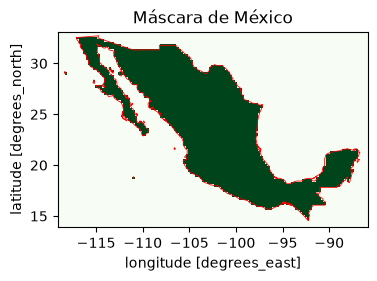

In [18]:
lon2d, lat2d = np.meshgrid(cube["lon"].values, cube["lat"].values)  
dentro_mexico = contains_xy(mexico_geom, lon2d, lat2d)

mexico_mask = xr.DataArray(
    dentro_mexico,
    coords={"lat": cube["lat"], "lon": cube["lon"]},
    dims=("lat", "lon"),
    name="mexico_mask",
)

fig, ax = plt.subplots(figsize=(4, 4))
mexico_mask.plot(ax=ax, cmap="Greens", add_colorbar=False)
mexico_gdf.boundary.plot(ax=ax, color="red", linewidth=0.6)
ax.set_title("Máscara de México")

In [19]:
def annual_utci_mode_stats(cube: xr.Dataset, mask: xr.DataArray) -> xr.Dataset:
    """Moda, frecuencia y conteo válido de categoría UTCI, por año y por celda.

    Parte de ``utci_max_diario`` (mismo índice que usa la app), lo clasifica con la
    tabla de estrés UTCI estándar y reduce la dimensión ``time`` a ``year``.

    Devuelve un ``xr.Dataset`` con dims ``(year, lat, lon)`` para la mayoría de las
    variables, salvo ``utci_category_pct`` que además tiene dim ``categoria`` (10):
      - ``utci_mode``: categoría dominante (0-9, ver ``atlas.indices.UTCI_STRESS``).
      - ``utci_frequency``: fracción de días válidos en esa categoría dominante.
      - ``valid_count``: días válidos usados (dentro de México, sin datos faltantes).
      - ``utci_category_pct``: % de días válidos en **cada** categoría (0-9), no
        solo la dominante — dims ``(year, categoria, lat, lon)``.
    """
    ix = indices.get("utci_max_diario")
    n_cats = len(UTCI_STRESS)

    utci_horario = cube[ix.var].load()

    categoria_horaria = indices.classify_utci(utci_horario).astype("float32")

    categoria_horaria = categoria_horaria.where(mask)

    def _stats_un_anio(cat_anio: xr.DataArray) -> xr.Dataset:
        valid_count = cat_anio.notnull().sum("time")
        conteos = xr.concat(
            [(cat_anio == c).sum("time") for c in range(n_cats)],
            dim="categoria",
        ).assign_coords(categoria=np.arange(n_cats))

        hay_datos = valid_count > 0
        utci_mode = conteos.argmax("categoria").astype("float32").where(hay_datos)
        utci_frequency = (conteos.max("categoria") / valid_count).where(hay_datos)

        utci_category_pct = (100 * conteos / valid_count).where(hay_datos)

        return xr.Dataset(
            {
                "utci_mode": utci_mode,
                "utci_frequency": utci_frequency,
                "valid_count": valid_count,
                "utci_category_pct": utci_category_pct,
            }
        )

    resultado = categoria_horaria.groupby("time.year").map(_stats_un_anio)

    resultado["utci_mode"].attrs.update(
        long_name="Categoría UTCI dominante del año (moda)",
        categorias="UTCI_STRESS (0=frío extremo .. 9=calor extremo)",
    )
    resultado["utci_frequency"].attrs.update(
        long_name="Fracción de días válidos en utci_mode",
        units="fracción [0-1]",
    )
    resultado["valid_count"].attrs.update(
        long_name="Días válidos usados (dentro de México, sin faltantes)",
        units="días",
    )
    resultado["utci_category_pct"].attrs.update(
        long_name="Porcentaje de días válidos en cada categoría UTCI",
        units="%",
        categorias="UTCI_STRESS (0=frío extremo .. 9=calor extremo)",
    )

    etiquetas = [c.label for c in UTCI_STRESS]
    resultado = resultado.assign_coords(categoria_label=("categoria", etiquetas))

    return resultado

In [20]:
resultado = annual_utci_mode_stats(cube, mexico_mask)
resultado

<xarray.Dataset> Size: 1MB
Dimensions:            (year: 1, lat: 77, lon: 133, categoria: 10)
Coordinates:
  * year               (year) int64 8B 2022
  * lat                (lat) float64 616B 14.0 14.25 14.5 ... 32.5 32.75 33.0
  * lon                (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.25 -86.0
  * categoria          (categoria) int64 80B 0 1 2 3 4 5 6 7 8 9
    categoria_label    (categoria) <U27 1kB 'Estrés por frío extremo' ... 'Es...
Data variables:
    utci_mode          (year, lat, lon) float32 41kB nan nan nan ... nan nan nan
    utci_frequency     (year, lat, lon) float64 82kB nan nan nan ... nan nan nan
    valid_count        (year, lat, lon) int64 82kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    utci_category_pct  (year, categoria, lat, lon) float64 819kB nan nan ... nan

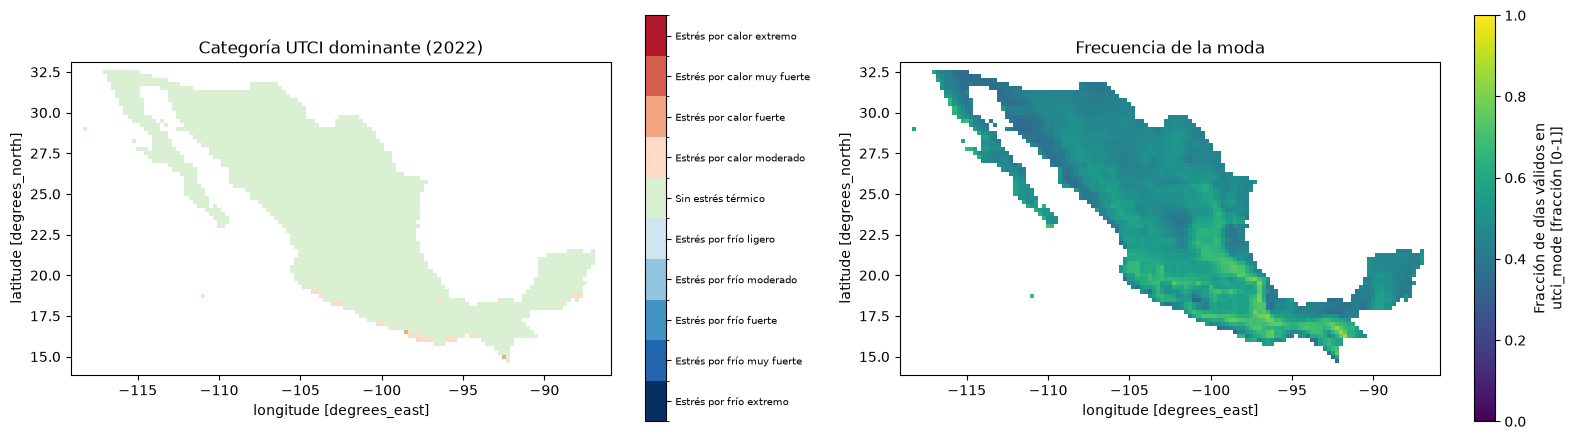

In [21]:
anio_a_graficar = int(resultado["year"].values[0])
r = resultado.sel(year=anio_a_graficar)

cmap_utci = ListedColormap([c.color for c in UTCI_STRESS])
norm_utci = BoundaryNorm(np.arange(-0.5, len(UTCI_STRESS) + 0.5, 1), cmap_utci.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

im0 = r["utci_mode"].plot(ax=axes[0], cmap=cmap_utci, norm=norm_utci, add_colorbar=False)
axes[0].set_title(f"Categoría UTCI dominante ({anio_a_graficar})")
cbar0 = fig.colorbar(im0, ax=axes[0], ticks=range(len(UTCI_STRESS)))
cbar0.ax.set_yticklabels([c.label for c in UTCI_STRESS], fontsize=7)

r["utci_frequency"].plot(ax=axes[1], cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Frecuencia de la moda")

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()

In [22]:
etiqueta_por_categoria = {c.idx: c.label for c in UTCI_STRESS}

tabla = (
    resultado.sel(year=anio_a_graficar)
    .to_dataframe()
    .reset_index()
    .dropna(subset=["utci_mode"]) 
)

tabla["utci_mode"] = tabla["utci_mode"].astype(int)
tabla["categoria"] = tabla["utci_mode"].map(etiqueta_por_categoria)
tabla = tabla[["lat", "lon", "categoria", "utci_mode", "utci_frequency"]]
tabla = tabla.sort_values("utci_frequency", ascending=False).reset_index(drop=True)

display(tabla.head(20))  


,lat,lon,categoria,utci_mode,utci_frequency
0,16.25,-91.75,Sin estrés térmico,5,0.852055
1,16.25,-91.75,Sin estrés térmico,5,0.852055
2,16.25,-91.75,Sin estrés térmico,5,0.852055
3,16.25,-91.75,Sin estrés térmico,5,0.852055
4,16.25,-91.75,Sin estrés térmico,5,0.852055
5,16.25,-91.75,Sin estrés térmico,5,0.852055
6,16.25,-91.75,Sin estrés térmico,5,0.852055
7,16.25,-91.75,Sin estrés térmico,5,0.852055
8,16.25,-91.75,Sin estrés térmico,5,0.852055
9,16.25,-91.75,Sin estrés térmico,5,0.852055


In [23]:
tabla_pct = (
    resultado.sel(year=anio_a_graficar)["utci_category_pct"]
    .to_dataframe()
    .reset_index()
    .dropna(subset=["utci_category_pct"]) 
)

tabla_pct = tabla_pct[["lat", "lon", "categoria_label", "utci_category_pct"]]

display(tabla_pct.sort_values(["lat", "lon", "utci_category_pct"], ascending=[True, True, False]).head(30))


,lat,lon,categoria_label,utci_category_pct
51711,14.75,-92.25,Sin estrés térmico,34.988584
72193,14.75,-92.25,Estrés por calor fuerte,34.006849
61952,14.75,-92.25,Estrés por calor moderado,26.986301
82434,14.75,-92.25,Estrés por calor muy fuerte,4.018265
506,14.75,-92.25,Estrés por frío extremo,0.000000
10747,14.75,-92.25,Estrés por frío muy fuerte,0.000000
20988,14.75,-92.25,Estrés por frío fuerte,0.000000
31229,14.75,-92.25,Estrés por frío moderado,0.000000
41470,14.75,-92.25,Estrés por frío ligero,0.000000
92675,14.75,-92.25,Estrés por calor extremo,0.000000


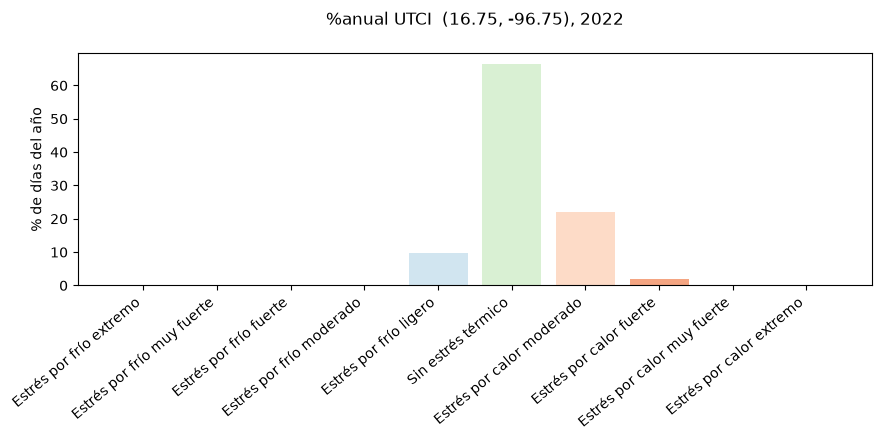

In [24]:
#huajuapan
# lat_punto = 17.81
# lon_punto = -97.78
#lugar frio
lat_punto = 16.75
lon_punto = -96.75

punto = resultado.sel(year=anio_a_graficar).sel(lat=lat_punto, lon=lon_punto, method="nearest")
pct_punto = punto["utci_category_pct"]

colores = [c.color for c in UTCI_STRESS]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(pct_punto["categoria_label"].values, pct_punto.values, color=colores)
ax.set_ylabel("% de días del año")
ax.set_title(
    f"%anual UTCI  "
    f"({float(punto.lat):.2f}, {float(punto.lon):.2f}), {anio_a_graficar}\n"
)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

In [25]:
#resultado.to_netcdf("../data/processed/utci_moda_anual.nc")